# <font color="black">**Assignment - 1: Auditing and Exploiting Low-Rank Approximation's Assumptions**</font>


### **Course: Foundation of Large Language Models (AI60213)**
### <font color="red">**Due date: September-17-2026**</font>

## Advisory

<font color="red"><b>Using generative AI tools to complete the assignment is discouraged, as it increases the probability of plagiarism with others who may choose the same approach. If Generative AI tools were used, please briefly mention the purpose and the relevant parts of the assignment where they were used.</b></font>

## Compute Requirements

1. One mid-range GPU (T-4) is sufficient for all experiments.
2. A small encoder model, BERT-base, must be used to ensure consistency.

## Submission Instructions

1. Only one member from each group needs to submit the assignment through Moodle to avoid any duplicate submissions.
2. Submit the Solution file as: **`Group(number)_assignment_1_solution.ipynb`** and a **`Group(number)_assignment_1_solution.py`** file as well.

## Plagiarism Policy

1. Code plagiarism will be checked on the designated blocks which the students have to code.
2. No penalty till 30% (Baseline).
3. Each 10% increase over baseline will cost 1 mark, Beyond 70% absolute-2 (negative).
4. Two groups having similar code will be penalized with the same amount. No arbitration will be done.
5. Late submission policy: One week window with a penalty of 3 marks.

## Setup Instructions

1. Pick a small pretrained model, such as **BERT-base**.
2. Pick a GLUE-style <font color="red">([https://huggingface.co/datasets/nyu-mll/glue/](https://huggingface.co/datasets/nyu-mll/glue/))</font> classification task, such as **MRPC** (two-class sentence equivalence, small, 6k samples) and **SST-2** (two-class sentiment, medium, 70k samples).
3. This assignment rewards depth of analysis.

In [1]:
## ------Start-----##

## <font color="blue"><b>Part-1: Empirically Audit the Low-Rank Approximation Hypothesis.</b></font>


LoRA rests on the claim that the weight update

$$
\Delta W = W_{\text{finetuned}} - W_{\text{pretrained}}
$$

has low intrinsic rank. Empirically test this claim using **BERT-base**.
_________

###<font color="purple">**Part 1.1 Full Fine-Tuning — 1 mark**</font>
Fully fine-tune BERT-base on two tasks:
- Sentiment classification
- Sentence equivalence classification

Use standard full fine-tuning (**no LoRA**) and save both checkpoints.
_______________

### <font color="green">**Part 1.2. Compute Weight Updates — 1 mark**</font>
For **every Q, K, V, O projection and FFN matrix across all layers**, compute:

$$
\Delta W_\ell =
W_\ell^{(\text{finetuned})} -
W_\ell^{(\text{pretrained})}.
$$
_________

### <font color="purple">**Part 1.3. SVD and Effective Rank — 2 marks**</font>
For every $\Delta W_\ell$, compute its singular values using SVD and determine the smallest $k$ for which the top-$k$ singular values capture:

- **90%** of the Frobenius norm
- **99%** of the Frobenius norm
___________

### <font color="green">**Part 1.4. Plots and Two-Task Comparison — 3 marks**</font>

For **each task**, produce:

1. **Effective Rank vs. Layer Depth**
   - X-axis: Layer depth
   - Y-axis: Effective rank
   - Show both **90% and 99%** ranks
   - Distinguish **Q, K, V, O, and FFN**

2. **Effective Rank vs. Matrix Type**
   - X-axis: Matrix type (**Q, K, V, O, FFN**)
   - Y-axis: Effective rank
   - Show both **90% and 99%** ranks
   - Preserve layer-wise results; do not report only a single average.

3. **Per-Matrix Heatmap**
   - X-axis: Matrix type
   - Y-axis: Layer depth
   - Cell value: Effective rank
   - Provide separate **90% and 99%** heatmaps.

4. **Cross-Task Comparison**
   - Overlay the **rank-vs-depth** profiles of both tasks.
   - Compare **rank-by-matrix-type** across both tasks.
   - Use the same axes/scales for direct comparison.

5. **Full Per-Matrix Table**
   - Report **Task, Layer, Matrix Type, 90% Rank, and 99% Rank** for every matrix.
   - **No averaging or omission of individual matrices.**
___________________________

<font color="red"><b><i>Note:</i></b> Complete the coding only in the designated sections marked <b><code>## Code Here ##</code></b> and complete the reflections/answers only in the designated sections marked <b><code>## ANSWER HERE ##</code></b>. Do not modify the provided code or questions outside these sections unless explicitly instructed. Ensure that all implementations, required outputs, plots, reflections, and analyses are complete and address the requirements of each question.</font>

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import TensorDataset, DataLoader
from datasets import load_dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

In [3]:
MODEL_NAME = "bert-base-uncased"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_LEN, BATCH_SIZE, EPOCHS, LR = 128, 64, 2, 2e-5

# GLUE task - datasets.
TASK_FIELDS = {
    "sst2": ("sentence", None),
    "mrpc": ("sentence1", "sentence2"),
}
MATRIX_ORDER = ["Q", "K", "V", "O", "FFN_in", "FFN_out"]

_______________
Tokenize via `datasets.map(batched=True)` (avoids the datasets-5.x lazy Column bug); convert to tensors once with explicit dtype=torch.long. Handles both single-sentence (SST-2) and sentence-pair (MRPC) tasks.
_______________

In [4]:
def build_loaders(task, tokenizer):
    """Build deterministic PyTorch loaders for GLUE SST-2 or MRPC.

    Dictionary batches are retained so BERT receives every relevant tokenizer
    output, including token_type_ids for sentence-pair tasks such as MRPC.
    """
    if task not in TASK_FIELDS:
        raise ValueError(
            f"Unsupported task: {task}. Choose from {list(TASK_FIELDS)}"
        )

    field1, field2 = TASK_FIELDS[task]

    # Use the canonical Hugging Face repository ID.
    dataset = load_dataset("nyu-mll/glue", task)

    def tokenize_batch(batch):
        if field2 is None:
            return tokenizer(
                batch[field1],
                truncation=True,
                padding="max_length",
                max_length=MAX_LEN,
            )

        return tokenizer(
            batch[field1],
            batch[field2],
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
        )

    encoded = dataset.map(tokenize_batch, batched=True)

    tensor_columns = ["input_ids", "attention_mask", "label"]
    if "token_type_ids" in encoded["train"].column_names:
        tensor_columns.append("token_type_ids")

    encoded.set_format(type="torch", columns=tensor_columns)

    generator = torch.Generator()
    generator.manual_seed(SEED)

    train_loader = DataLoader(
        encoded["train"],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        pin_memory=torch.cuda.is_available(),
    )

    val_loader = DataLoader(
        encoded["validation"],
        batch_size=BATCH_SIZE,
        shuffle=False,
        pin_memory=torch.cuda.is_available(),
    )

    return train_loader, val_loader


def move_batch_to_device(batch):
    """Move one dictionary batch to DEVICE and separate the labels."""
    batch = {
        key: value.to(DEVICE, non_blocking=True)
        for key, value in batch.items()
    }

    if "labels" in batch:
        labels = batch.pop("labels")
    elif "label" in batch:
        labels = batch.pop("label")
    else:
        raise KeyError("Batch contains neither 'label' nor 'labels'.")

    return batch, labels


_________
Snapshot only 2D encoder-layer weights (Q/K/V/O + FFN). Embeddings -> Part C; classifier head is random-init, so its "delta" is excluded.
___________

In [5]:
def linear_weight_snapshot(model):
    """Copy all encoder Q/K/V/O and FFN 2-D weight matrices to CPU."""
    snapshot = {}
    for name, param in model.named_parameters():
        if not name.startswith("bert.encoder.layer."):
            continue
        if not name.endswith(".weight") or param.ndim != 2:
            continue
        if classify_matrix(name) == "other":
            continue
        snapshot[name] = param.detach().cpu().float().clone()
    return snapshot


@torch.no_grad()
def evaluate(model, loader):
    """Return accuracy and mean validation loss."""
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0.0

    for batch in loader:
        model_inputs, labels = move_batch_to_device(batch)

        out = model(
            **model_inputs,
            labels=labels,
        )

        loss_sum += out.loss.item() * labels.size(0)
        correct += (out.logits.argmax(dim=-1) == labels).sum().item()
        total += labels.size(0)

    if total == 0:
        raise ValueError("Validation loader is empty.")

    return correct / total, loss_sum / total


_________
effective rank: smallest k s.t. top-k singular values capture `energy`
fraction of the Frobenius norm.  ||dW||_F^2 = sum(sigma_i^2)  ->  threshold
on cumulative SQUARED singular values.
_________

In [6]:
def effective_rank(delta, energy):
    """Smallest k whose squared singular values explain `energy` of ||delta||_F^2."""
    if not (0.0 < energy <= 1.0):
        raise ValueError("energy must lie in (0, 1].")

    # SVD is the expensive step. Move one matrix at a time to the accelerator,
    # then immediately return only the scalar rank.
    x = delta.to(DEVICE, dtype=torch.float32)
    s = torch.linalg.svdvals(x)
    sq = s.square()
    total = sq.sum()

    # A genuinely zero update has effective rank 0.
    if total.item() == 0.0:
        return 0

    cumulative = torch.cumsum(sq, dim=0) / total
    k = torch.searchsorted(
        cumulative,
        torch.tensor(energy, device=cumulative.device, dtype=cumulative.dtype),
        right=False,
    ).item() + 1
    return int(k)

def classify_matrix(name):
    if "attention.self.query"   in name: return "Q"
    if "attention.self.key"     in name: return "K"
    if "attention.self.value"   in name: return "V"
    if "attention.output.dense" in name: return "O"
    if "intermediate.dense"     in name: return "FFN_in"
    if "output.dense"           in name: return "FFN_out"
    return "other"





_____________
full fine-tune then audit EVERY matrix. One record per matrix
(layer, mtype, k90, k99, dim) -> nothing is averaged away at this stage.
_____________

In [7]:
def finetune_and_audit(task):
    import os
    import re

    print(f"\n########## TASK: {task} ##########")
    set_seed(SEED)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
    ).to(DEVICE)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # Snapshot the pretrained encoder weights before any optimisation.
    pretrained = linear_weight_snapshot(model)

    train_loader, val_loader = build_loaders(task, tokenizer)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=0.01,
    )

    total_steps = len(train_loader) * EPOCHS

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.06 * total_steps),
        num_training_steps=total_steps,
    )

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0

        for step, batch in enumerate(train_loader, start=1):
            model_inputs, labels = move_batch_to_device(batch)

            optimizer.zero_grad(set_to_none=True)

            out = model(
                **model_inputs,
                labels=labels,
            )

            loss = out.loss
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()
            scheduler.step()

            running_loss += loss.item()

            if step % 200 == 0:
                print(
                    f"  epoch {epoch} step {step}/{len(train_loader)} "
                    f"loss {running_loss / 200:.4f}"
                )
                running_loss = 0.0

        acc, val_loss = evaluate(model, val_loader)

        print(
            f"  [epoch {epoch}] "
            f"val_acc={acc:.4f} "
            f"val_loss={val_loss:.4f}"
        )

    acc, _ = evaluate(model, val_loader)
    print(f"  FINAL {task} val accuracy: {acc:.4f}")

    checkpoint_dir = os.path.join("checkpoints", f"ft_{task}")
    os.makedirs(checkpoint_dir, exist_ok=True)
    model.save_pretrained(checkpoint_dir)
    tokenizer.save_pretrained(checkpoint_dir)
    print(f"  Saved checkpoint to: {checkpoint_dir}")

    finetuned = linear_weight_snapshot(model)

    rows = []

    for name in sorted(pretrained.keys()):
        if name not in finetuned:
            raise KeyError(f"Missing fine-tuned matrix: {name}")

        delta = finetuned[name] - pretrained[name]

        match = re.search(
            r"bert\.encoder\.layer\.(\d+)\.",
            name,
        )

        if match is None:
            continue

        layer = int(match.group(1))
        mtype = classify_matrix(name)

        k90 = effective_rank(delta, 0.90)
        k99 = effective_rank(delta, 0.99)

        rows.append(
            {
                "task": task.upper(),
                "name": name,
                "layer": layer,
                "mtype": mtype,
                "k90": k90,
                "k99": k99,
                "rows": int(delta.shape[0]),
                "cols": int(delta.shape[1]),
                "fro_norm": float(
                    torch.linalg.vector_norm(delta).item()
                ),
            }
        )

        print(
            f"  layer={layer:2d} "
            f"{mtype:7s} "
            f"shape={tuple(delta.shape)!s:14s} "
            f"k90={k90:4d} "
            f"k99={k99:4d}"
        )

    if len(rows) != 72:
        print(
            "WARNING: expected 72 audited matrices for BERT-base, "
            f"found {len(rows)}"
        )

    return rows


In [8]:
rows_sst2 = finetune_and_audit("sst2")
rows_mrpc = finetune_and_audit("mrpc")
ALL_TASKS = [("SST-2", rows_sst2), ("MRPC", rows_mrpc)]


########## TASK: sst2 ##########


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1 step 200/1053 loss 0.4318
  epoch 1 step 400/1053 loss 0.2353
  epoch 1 step 600/1053 loss 0.1949
  epoch 1 step 800/1053 loss 0.1831
  epoch 1 step 1000/1053 loss 0.1715
  [epoch 1] val_acc=0.9243 val_loss=0.2194
  epoch 2 step 200/1053 loss 0.1163
  epoch 2 step 400/1053 loss 0.1072
  epoch 2 step 600/1053 loss 0.1076
  epoch 2 step 800/1053 loss 0.1008
  epoch 2 step 1000/1053 loss 0.1054
  [epoch 2] val_acc=0.9278 val_loss=0.2587
  FINAL sst2 val accuracy: 0.9278


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  [epoch 1] val_acc=0.7721 val_loss=0.5029
  [epoch 2] val_acc=0.7941 val_loss=0.4714
  FINAL mrpc val accuracy: 0.7941


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Saved checkpoint to: checkpoints/ft_mrpc
  layer= 0 O       shape=(768, 768)     k90= 190 k99= 462
  layer= 0 K       shape=(768, 768)     k90= 213 k99= 475
  layer= 0 Q       shape=(768, 768)     k90= 236 k99= 490
  layer= 0 V       shape=(768, 768)     k90= 177 k99= 448
  layer= 0 FFN_in  shape=(3072, 768)    k90= 438 k99= 697
  layer= 0 FFN_out shape=(768, 3072)    k90= 402 k99= 693
  layer= 1 O       shape=(768, 768)     k90= 174 k99= 447
  layer= 1 K       shape=(768, 768)     k90= 209 k99= 468
  layer= 1 Q       shape=(768, 768)     k90= 216 k99= 469
  layer= 1 V       shape=(768, 768)     k90= 147 k99= 424
  layer= 1 FFN_in  shape=(3072, 768)    k90= 427 k99= 695
  layer= 1 FFN_out shape=(768, 3072)    k90= 376 k99= 686
  layer=10 O       shape=(768, 768)     k90=  75 k99= 364
  layer=10 K       shape=(768, 768)     k90= 143 k99= 420
  layer=10 Q       shape=(768, 768)     k90= 129 k99= 408
  layer=10 V       shape=(768, 768)     k90=  75 k99= 353
  layer=10 FFN_in  shape=(307

In [9]:
print(type(ALL_TASKS))
print(len(ALL_TASKS))

for task, rows in ALL_TASKS:
    print(task, len(rows))

<class 'list'>
2
SST-2 72
MRPC 72


In [10]:
# =============================================================================
# FULL per-matrix table — one row per matrix, NO averaging.
# Raw evidence (72 rows for BERT-base: 12 layers x 6 types). Run for BOTH tasks.
# =============================================================================
def per_matrix_table(rows, task):
    import pandas as pd
    order = {m: i for i, m in enumerate(MATRIX_ORDER)}
    data = sorted(rows, key=lambda r: (r["layer"], order[r["mtype"]]))
    df = pd.DataFrame([{
        "Task": task,
        "Layer": r["layer"],
        "Matrix Type": r["mtype"],
        "90% Rank": r["k90"],
        "99% Rank": r["k99"],
        "Shape": f'{r["rows"]}x{r["cols"]}',
    } for r in data])
    print(f"\n===== Full per-matrix effective-rank table: {task} =====")
    try:
        from IPython.display import display
        display(df)
    except Exception:
        print(df.to_string(index=False))
    return df

for task, rows in ALL_TASKS:
    per_matrix_table(rows, task)



===== Full per-matrix effective-rank table: SST-2 =====


,Task,Layer,Matrix Type,90% Rank,99% Rank,Shape
0,SST-2,0,Q,235,482,768x768
1,SST-2,0,K,234,482,768x768
2,SST-2,0,V,207,463,768x768
3,SST-2,0,O,219,475,768x768
4,SST-2,0,FFN_in,446,697,3072x768
...,...,...,...,...,...,...
67,SST-2,11,K,115,376,768x768
68,SST-2,11,V,36,237,768x768
69,SST-2,11,O,26,230,768x768
70,SST-2,11,FFN_in,78,470,3072x768



===== Full per-matrix effective-rank table: MRPC =====


,Task,Layer,Matrix Type,90% Rank,99% Rank,Shape
0,MRPC,0,Q,236,490,768x768
1,MRPC,0,K,213,475,768x768
2,MRPC,0,V,177,448,768x768
3,MRPC,0,O,190,462,768x768
4,MRPC,0,FFN_in,438,697,3072x768
...,...,...,...,...,...,...
67,MRPC,11,K,124,388,768x768
68,MRPC,11,V,44,300,768x768
69,MRPC,11,O,24,265,768x768
70,MRPC,11,FFN_in,55,445,3072x768


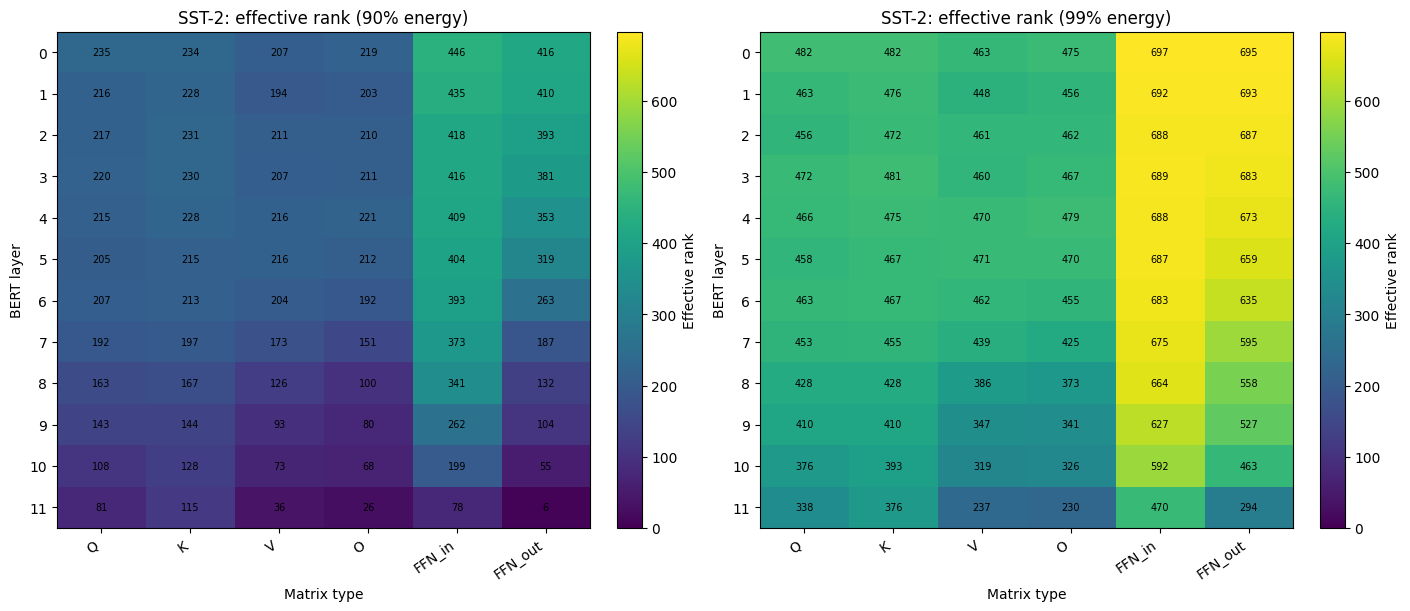

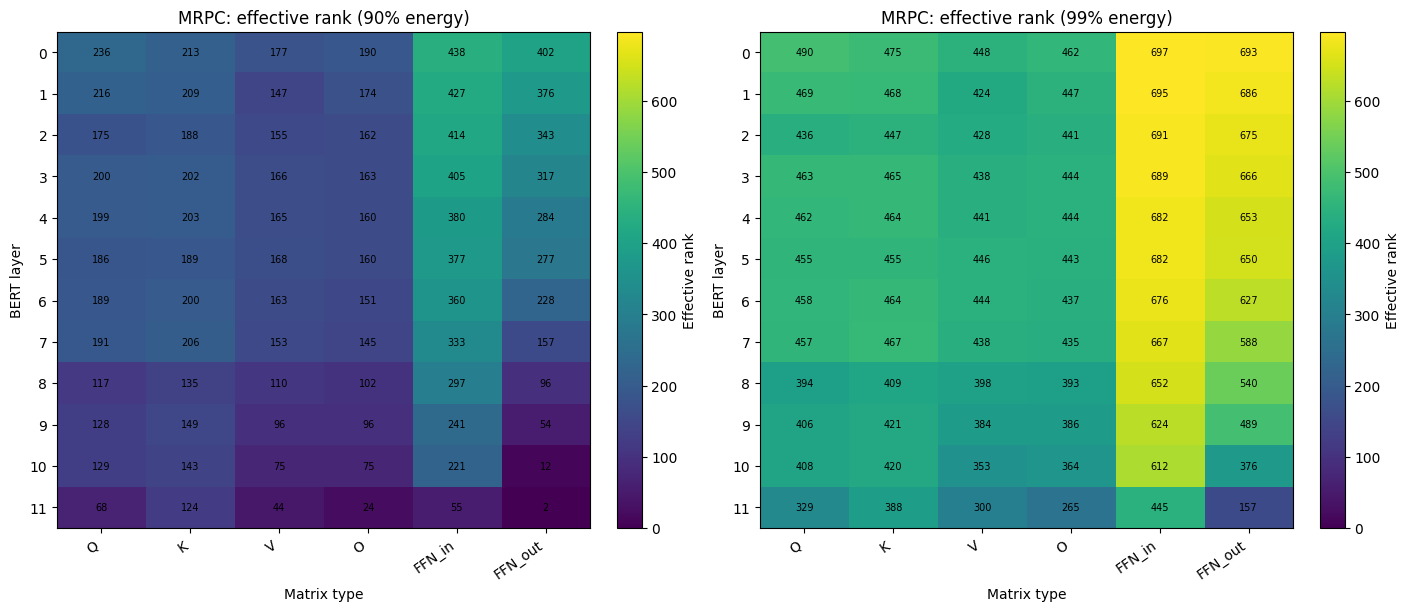

In [11]:
# =============================================================================
# HEATMAP — every layer x matrix-type cell at once (k90 and k99). BOTH tasks.
# =============================================================================
def plot_heatmap(rows, task):
    layer_ids = sorted({r["layer"] for r in rows})
    lookup = {(r["layer"], r["mtype"]): r for r in rows}

    matrices = {}
    for key in ("k90", "k99"):
        matrices[key] = np.array([
            [lookup[(layer, mtype)][key] for mtype in MATRIX_ORDER]
            for layer in layer_ids
        ], dtype=float)

    vmax = max(matrices["k90"].max(), matrices["k99"].max())
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    for ax, key, title in zip(axes, ("k90", "k99"), ("90% energy", "99% energy")):
        im = ax.imshow(matrices[key], aspect="auto", vmin=0, vmax=vmax)
        ax.set_title(f"{task}: effective rank ({title})")
        ax.set_xlabel("Matrix type")
        ax.set_ylabel("BERT layer")
        ax.set_xticks(range(len(MATRIX_ORDER)), MATRIX_ORDER, rotation=35, ha="right")
        ax.set_yticks(range(len(layer_ids)), layer_ids)
        for i in range(len(layer_ids)):
            for j in range(len(MATRIX_ORDER)):
                ax.text(j, i, int(matrices[key][i, j]), ha="center", va="center", fontsize=7)
        fig.colorbar(im, ax=ax, label="Effective rank")
    plt.show()

for task, rows in ALL_TASKS:
    plot_heatmap(rows, task)


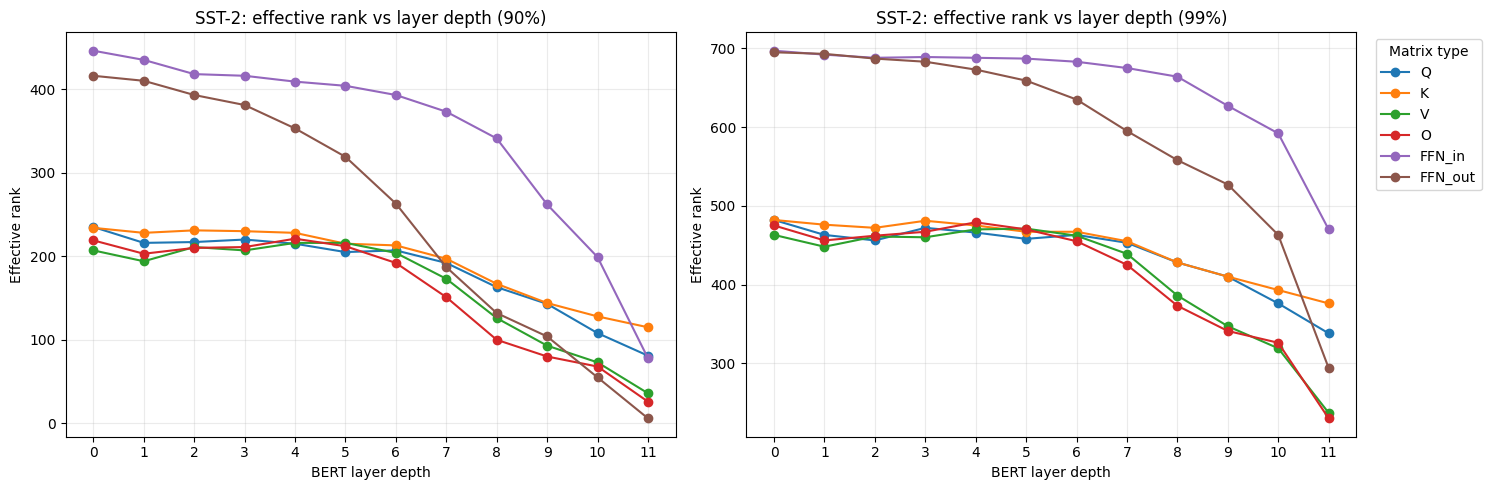

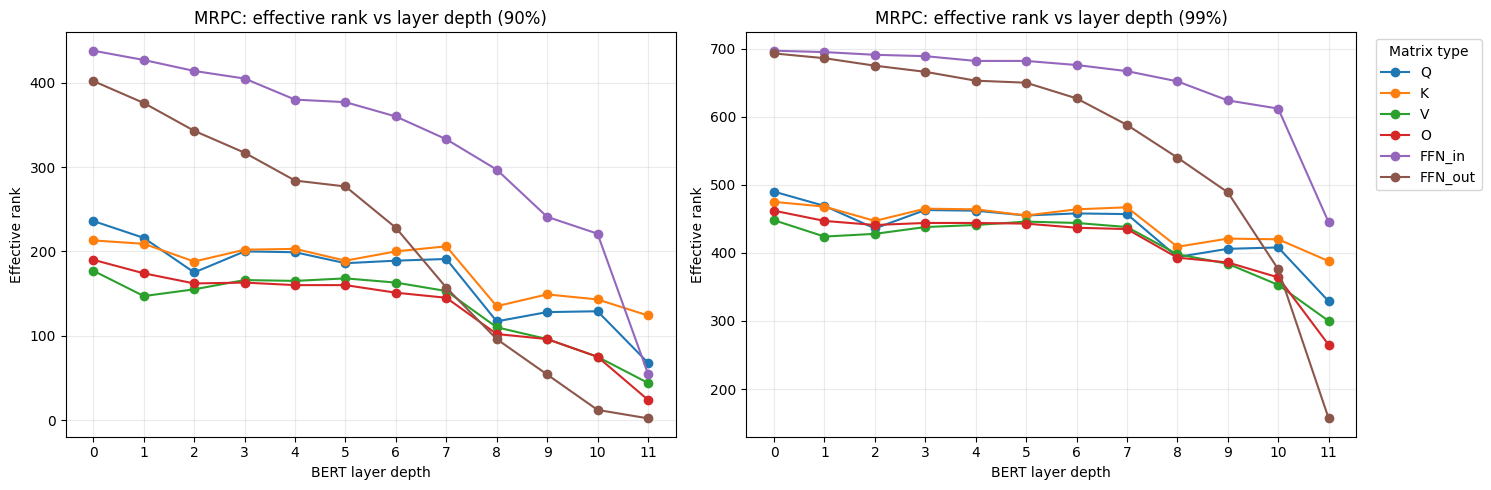

In [12]:
# =============================================================================
# PLOT 1 — effective rank vs. layer depth. Run for BOTH tasks.
#   Every matrix type is preserved; separate panels show @90% and @99%.
# =============================================================================
def plot_rank_vs_depth(rows, task):
    by = {(r["layer"], r["mtype"]): r for r in rows}
    layers = sorted({r["layer"] for r in rows})

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)
    for ax, key, label in zip(axes, ("k90", "k99"), ("90%", "99%")):
        for mtype in MATRIX_ORDER:
            ys = [by[(layer, mtype)][key] for layer in layers]
            ax.plot(layers, ys, marker="o", linewidth=1.5, label=mtype)
        ax.set_title(f"{task}: effective rank vs layer depth ({label})")
        ax.set_xlabel("BERT layer depth")
        ax.set_ylabel("Effective rank")
        ax.set_xticks(layers)
        ax.grid(alpha=0.25)
    axes[-1].legend(title="Matrix type", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

for task, rows in ALL_TASKS:
    plot_rank_vs_depth(rows, task)


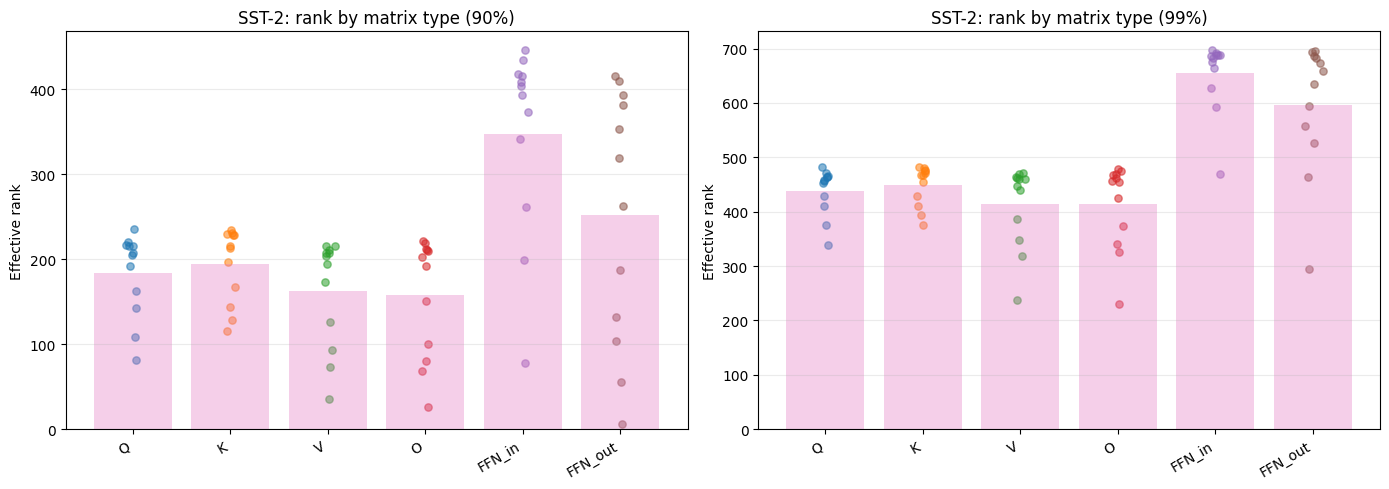

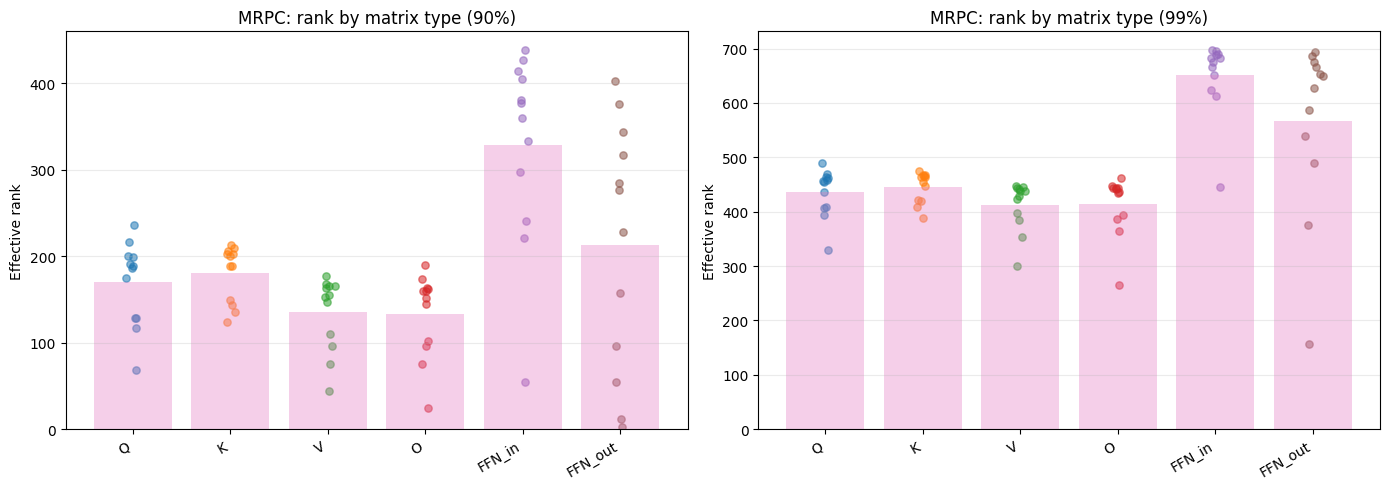

In [13]:
# =============================================================================
# PLOT 2 — effective rank vs. matrix type (Q/K/V/O/FFN). Run for BOTH tasks.
#   Bars = mean; scatter = every layer's matrix of that type.
# =============================================================================
def plot_rank_vs_type(rows, task):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    rng = np.random.default_rng(SEED)

    for ax, key, label in zip(axes, ("k90", "k99"), ("90%", "99%")):
        means = []
        for x, mtype in enumerate(MATRIX_ORDER):
            vals = np.array([r[key] for r in rows if r["mtype"] == mtype], dtype=float)
            means.append(vals.mean())
            jitter = rng.normal(0.0, 0.035, size=len(vals))
            ax.scatter(np.full(len(vals), x) + jitter, vals, alpha=0.55, s=28)
        ax.bar(np.arange(len(MATRIX_ORDER)), means, alpha=0.35)
        ax.set_xticks(np.arange(len(MATRIX_ORDER)), MATRIX_ORDER, rotation=30, ha="right")
        ax.set_ylabel("Effective rank")
        ax.set_title(f"{task}: rank by matrix type ({label})")
        ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

for task, rows in ALL_TASKS:
    plot_rank_vs_type(rows, task)


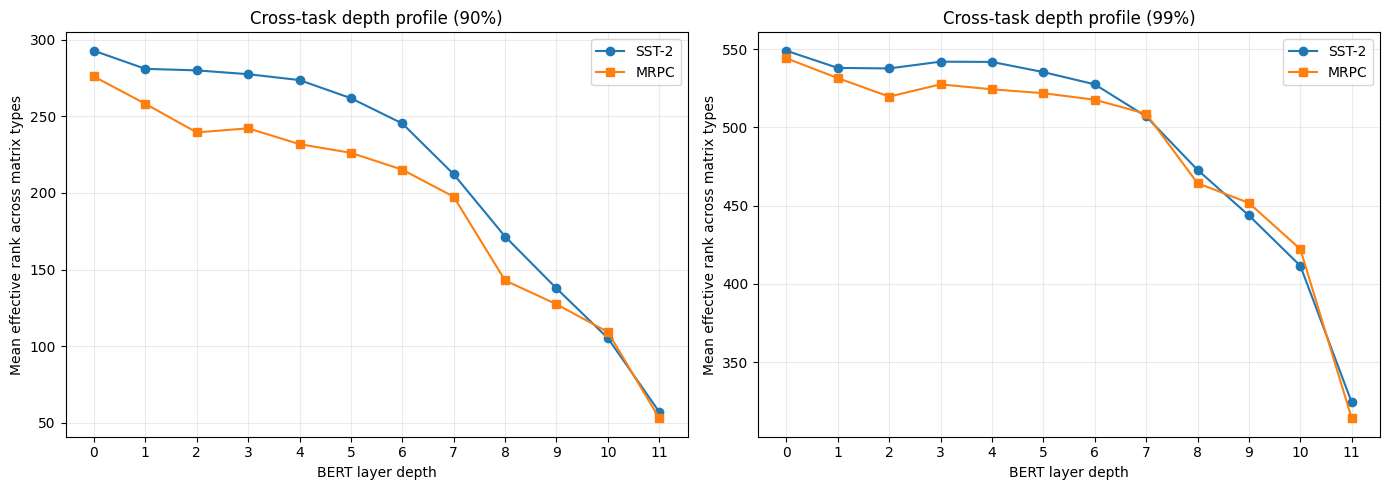

In [14]:
# =============================================================================
# CROSS-TASK 1 — overlaid depth profile (both tasks, one axis).
#   Layer-wise means are shown for both 90% and 99% ranks using the same axes.
# =============================================================================
def plot_depth_cross_task(rows_a, name_a, rows_b, name_b, key="k90"):
    def layer_means(rows, metric):
        out = defaultdict(list)
        for r in rows:
            out[r["layer"]].append(r[metric])
        layers = sorted(out)
        return layers, [float(np.mean(out[l])) for l in layers]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    for ax, metric, label in zip(axes, ("k90", "k99"), ("90%", "99%")):
        la, ya = layer_means(rows_a, metric)
        lb, yb = layer_means(rows_b, metric)
        ax.plot(la, ya, marker="o", label=name_a)
        ax.plot(lb, yb, marker="s", label=name_b)
        ax.set_title(f"Cross-task depth profile ({label})")
        ax.set_xlabel("BERT layer depth")
        ax.set_ylabel("Mean effective rank across matrix types")
        ax.set_xticks(sorted(set(la) | set(lb)))
        ax.grid(alpha=0.25)
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_depth_cross_task(rows_sst2, "SST-2", rows_mrpc, "MRPC")


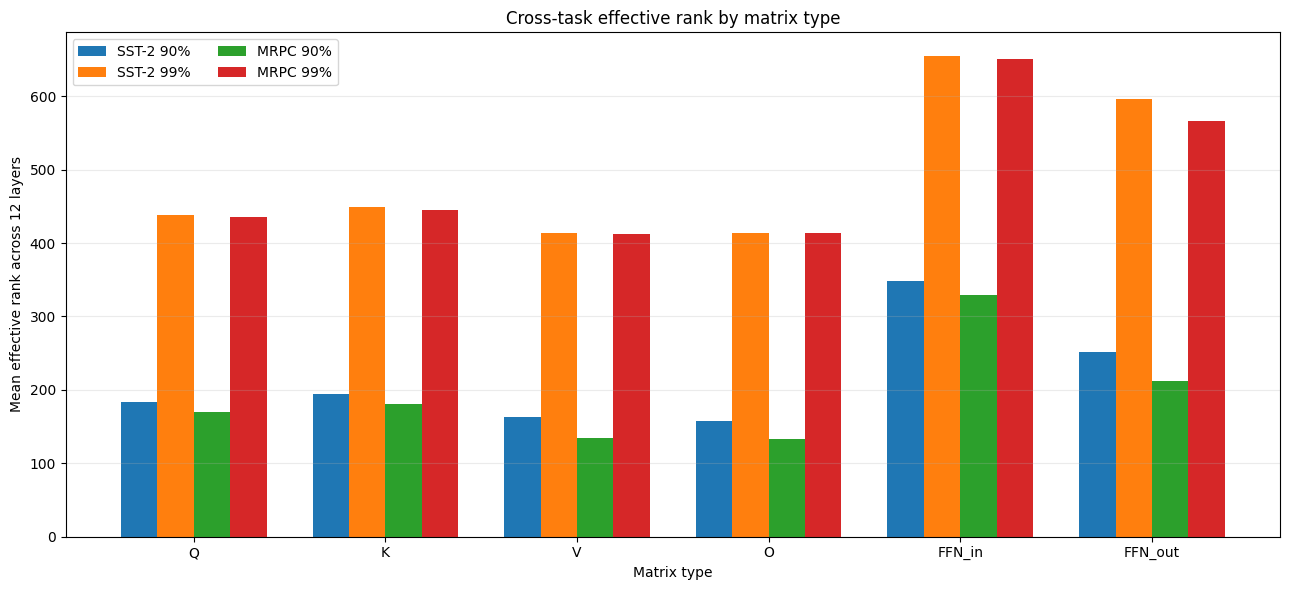

In [15]:
# =============================================================================
# CROSS-TASK 2 — rank by matrix type, both tasks side by side.
# =============================================================================
def plot_type_cross_task(rows_a, name_a, rows_b, name_b):
    x = np.arange(len(MATRIX_ORDER), dtype=float)
    width = 0.19
    fig, ax = plt.subplots(figsize=(13, 6))

    def means(rows, key):
        return [np.mean([r[key] for r in rows if r["mtype"] == m]) for m in MATRIX_ORDER]

    ax.bar(x - 1.5*width, means(rows_a, "k90"), width, label=f"{name_a} 90%")
    ax.bar(x - 0.5*width, means(rows_a, "k99"), width, label=f"{name_a} 99%")
    ax.bar(x + 0.5*width, means(rows_b, "k90"), width, label=f"{name_b} 90%")
    ax.bar(x + 1.5*width, means(rows_b, "k99"), width, label=f"{name_b} 99%")
    ax.set_xticks(x, MATRIX_ORDER)
    ax.set_xlabel("Matrix type")
    ax.set_ylabel("Mean effective rank across 12 layers")
    ax.set_title("Cross-task effective rank by matrix type")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()

plot_type_cross_task(rows_sst2, "SST-2", rows_mrpc, "MRPC")


In [16]:
# =============================================================================
# Aggregate by-type summary (means) — cite alongside Plot 2. BOTH tasks.
# =============================================================================
def summarize_by_type(rows, task):
    import pandas as pd
    summary = []
    for mtype in MATRIX_ORDER:
        subset = [r for r in rows if r["mtype"] == mtype]
        summary.append({
            "Task": task,
            "Matrix Type": mtype,
            "Mean k90": np.mean([r["k90"] for r in subset]),
            "Std k90": np.std([r["k90"] for r in subset], ddof=1),
            "Mean k99": np.mean([r["k99"] for r in subset]),
            "Std k99": np.std([r["k99"] for r in subset], ddof=1),
            "Min k90": min(r["k90"] for r in subset),
            "Max k90": max(r["k90"] for r in subset),
        })
    df = pd.DataFrame(summary)
    print(f"\n===== By-type summary: {task} =====")
    try:
        from IPython.display import display
        display(df.round(2))
    except Exception:
        print(df.round(2).to_string(index=False))
    return df

for task, rows in ALL_TASKS:
    summarize_by_type(rows, task)



===== By-type summary: SST-2 =====


,Task,Matrix Type,Mean k90,Std k90,Mean k99,Std k99,Min k90,Max k90
0,SST-2,Q,183.50,49.09,438.75,43.48,81,235
1,SST-2,K,194.17,43.91,448.50,37.12,115,234
2,SST-2,V,163.00,63.98,413.58,75.57,36,216
3,SST-2,O,157.75,70.27,413.25,78.83,26,221
4,SST-2,FFN_in,347.83,112.31,654.33,65.87,78,446
5,SST-2,FFN_out,251.58,148.64,596.83,121.19,6,416



===== By-type summary: MRPC =====


,Task,Matrix Type,Mean k90,Std k90,Mean k99,Std k99,Min k90,Max k90
0,MRPC,Q,169.50,48.57,435.58,44.30,68,236
1,MRPC,K,180.08,32.55,445.25,28.42,124,213
2,MRPC,V,134.92,43.06,411.83,45.80,44,177
3,MRPC,O,133.50,48.77,413.42,55.31,24,190
4,MRPC,FFN_in,329.00,111.14,651.00,70.44,55,438
5,MRPC,FFN_out,212.33,143.46,566.67,159.89,2,402


### <font color="red"><b>Reflection 1: </b></font>

**Q1 — Rank across layers & matrix types**

In [17]:
# Reflection 1, Q1: evidence-based summary generated from the measured ranks.
from IPython.display import Markdown, display

def _rank_stats(rows):
    type_stats = {
        m: (np.mean([r["k90"] for r in rows if r["mtype"] == m]),
            np.mean([r["k99"] for r in rows if r["mtype"] == m]))
        for m in MATRIX_ORDER
    }
    all90 = np.array([r["k90"] for r in rows])
    all99 = np.array([r["k99"] for r in rows])
    return type_stats, all90, all99

lines = ["### Q1. Rank across layers and matrix types", ""]
for task_name, rows in ALL_TASKS:
    ts, a90, a99 = _rank_stats(rows)
    ordered90 = sorted(ts.items(), key=lambda kv: kv[1][0], reverse=True)
    lines.append(
        f"For **{task_name}**, the measured 90% effective ranks span **{a90.min()} to {a90.max()}**, "
        f"while the 99% ranks span **{a99.min()} to {a99.max()}**. "
        f"The largest mean 90% rank occurs for **{ordered90[0][0]}** ({ordered90[0][1][0]:.1f}), "
        f"whereas the smallest occurs for **{ordered90[-1][0]}** ({ordered90[-1][1][0]:.1f})."
    )
    lines.append("")
lines.append(
    "The per-matrix table and heatmaps show that effective rank is not a single constant shared by all "
    "BERT transformations. Both layer identity and projection/FFN type affect the amount of rank needed "
    "to retain the fine-tuning update energy. The 99% criterion is consistently more demanding than the "
    "90% criterion because it must also retain lower-energy singular directions."
)
display(Markdown("\n".join(lines)))


### Q1. Rank across layers and matrix types

For **SST-2**, the measured 90% effective ranks span **6 to 446**, while the 99% ranks span **230 to 697**. The largest mean 90% rank occurs for **FFN_in** (347.8), whereas the smallest occurs for **O** (157.8).

For **MRPC**, the measured 90% effective ranks span **2 to 438**, while the 99% ranks span **157 to 697**. The largest mean 90% rank occurs for **FFN_in** (329.0), whereas the smallest occurs for **O** (133.5).

The per-matrix table and heatmaps show that effective rank is not a single constant shared by all BERT transformations. Both layer identity and projection/FFN type affect the amount of rank needed to retain the fine-tuning update energy. The 99% criterion is consistently more demanding than the 90% criterion because it must also retain lower-energy singular directions.

**Q2 — Rank vs. depth & task consistency**

In [18]:
# Reflection 1, Q2: quantify rank-depth association and cross-task consistency.
from IPython.display import Markdown, display

def _layer_profile(rows, key):
    d = defaultdict(list)
    for r in rows:
        d[r["layer"]].append(r[key])
    layers = np.array(sorted(d), dtype=float)
    vals = np.array([np.mean(d[int(l)]) for l in layers], dtype=float)
    return layers, vals

def _corr(x, y):
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return float("nan")
    return float(np.corrcoef(x, y)[0, 1])

l_s, p_s90 = _layer_profile(rows_sst2, "k90")
_,   p_s99 = _layer_profile(rows_sst2, "k99")
l_m, p_m90 = _layer_profile(rows_mrpc, "k90")
_,   p_m99 = _layer_profile(rows_mrpc, "k99")

rho_s90 = _corr(l_s, p_s90)
rho_m90 = _corr(l_m, p_m90)
cross90 = _corr(p_s90, p_m90)
cross99 = _corr(p_s99, p_m99)

def trend_word(rho):
    if np.isnan(rho) or abs(rho) < 0.2: return "little systematic"
    return "increasing" if rho > 0 else "decreasing"

text = f"""
### Q2. Rank versus depth and task consistency

Using the mean effective rank across the six audited matrix types at each encoder depth, the correlation between layer index and the 90% effective rank is **{rho_s90:.3f}** for SST-2 and **{rho_m90:.3f}** for MRPC. Thus, SST-2 shows **{trend_word(rho_s90)}** rank-with-depth behaviour, while MRPC shows **{trend_word(rho_m90)}** behaviour.

More importantly, the correlation between the two tasks' layer-wise profiles is **{cross90:.3f}** at 90% energy and **{cross99:.3f}** at 99% energy. A high positive cross-task correlation indicates an architectural component to the rank profile because the same BERT layers tend to occupy similar relative positions in both tasks. Deviations between the curves indicate a task-dependent component. Therefore, the evidence should be interpreted as showing that intrinsic rank is a property of **both the model structure and the downstream task**, with the relative strength of the two effects visible in the cross-task plots and correlations above.
"""
display(Markdown(text))



### Q2. Rank versus depth and task consistency

Using the mean effective rank across the six audited matrix types at each encoder depth, the correlation between layer index and the 90% effective rank is **-0.933** for SST-2 and **-0.949** for MRPC. Thus, SST-2 shows **decreasing** rank-with-depth behaviour, while MRPC shows **decreasing** behaviour.

More importantly, the correlation between the two tasks' layer-wise profiles is **0.991** at 90% energy and **0.992** at 99% energy. A high positive cross-task correlation indicates an architectural component to the rank profile because the same BERT layers tend to occupy similar relative positions in both tasks. Deviations between the curves indicate a task-dependent component. Therefore, the evidence should be interpreted as showing that intrinsic rank is a property of **both the model structure and the downstream task**, with the relative strength of the two effects visible in the cross-task plots and correlations above.


**Q3 — Implication for LoRA allocation**


In [19]:
# Reflection 1, Q3: derive the LoRA implication directly from measured heterogeneity.
from IPython.display import Markdown, display

all_rows = rows_sst2 + rows_mrpc
k90_vals = np.array([r["k90"] for r in all_rows], dtype=float)
cv = float(k90_vals.std(ddof=1) / k90_vals.mean()) if k90_vals.mean() else 0.0

# Identify matrix types with relatively high/low measured capacity demand.
type_means = {
    m: np.mean([r["k90"] for r in all_rows if r["mtype"] == m])
    for m in MATRIX_ORDER
}
high_types = sorted(type_means, key=type_means.get, reverse=True)[:2]
low_types = sorted(type_means, key=type_means.get)[:2]

text = f"""
### Q3. Implication for LoRA rank allocation

The combined 90% effective-rank measurements have a coefficient of variation of **{cv:.3f}**, so the required low-rank capacity is not uniform across the audited matrices. The two matrix types with the largest mean measured 90% ranks are **{high_types[0]}** and **{high_types[1]}**, whereas **{low_types[0]}** and **{low_types[1]}** have the smallest means.

These observations do **not** provide strong empirical support for assigning exactly the same LoRA rank to every layer and matrix type. A more data-informed strategy is to allocate larger ranks to matrices whose full-fine-tuning updates require more singular directions, and smaller ranks to matrices whose updates are strongly concentrated in fewer directions. Such an allocation should still be compared with uniform-rank LoRA under a **matched total trainable-parameter budget**. Otherwise, a variable-rank method could appear better simply because it has more parameters rather than because the capacity was placed more effectively.

Part 2 should therefore test whether redistributing a fixed LoRA parameter budget according to this measured effective-rank profile improves downstream validation performance. This is an empirical consequence of the Part 1 audit rather than an assumption taken from the LoRA literature.
"""
display(Markdown(text))



### Q3. Implication for LoRA rank allocation

The combined 90% effective-rank measurements have a coefficient of variation of **0.521**, so the required low-rank capacity is not uniform across the audited matrices. The two matrix types with the largest mean measured 90% ranks are **FFN_in** and **FFN_out**, whereas **O** and **V** have the smallest means.

These observations do **not** provide strong empirical support for assigning exactly the same LoRA rank to every layer and matrix type. A more data-informed strategy is to allocate larger ranks to matrices whose full-fine-tuning updates require more singular directions, and smaller ranks to matrices whose updates are strongly concentrated in fewer directions. Such an allocation should still be compared with uniform-rank LoRA under a **matched total trainable-parameter budget**. Otherwise, a variable-rank method could appear better simply because it has more parameters rather than because the capacity was placed more effectively.

Part 2 should therefore test whether redistributing a fixed LoRA parameter budget according to this measured effective-rank profile improves downstream validation performance. This is an empirical consequence of the Part 1 audit rather than an assumption taken from the LoRA literature.


## <font color="blue"><b>Part-2: Rank Allocation and Layer-wise Adaptation Informed by Your Own Data. </b></font>

Using the effective-rank profile measured in **Part-1** (not a heuristic from any paper), investigate how the **amount, location, and type of adaptation** affect performance. All comparisons should use a **matched total trainable-parameter budget** wherever applicable.

---

### <font color="purple">Part 2.1: Implement LoRA — 1 mark</font>

Implement standard per-layer LoRA (`LoRALinear`).

---


### <font color="green">Part 2.2: How Much LoRA Capacity Is Needed? — 1 mark</font>

Train and compare the following LoRA configurations under a **matched total trainable-parameter budget**:

1. **Uniform-rank LoRA:** use the same rank $r$ across all selected layers (e.g., $r=8$ everywhere).

2. **Data-informed variable-rank LoRA:** assign a rank $r_\ell$ to each layer based on its measured effective rank from **Part-1**. Use a common rank scale (e.g., $r_\ell \in \{8,16,32,\ldots\}$) and adjust the allocation so that the total number of trainable parameters matches the uniform-rank baseline.

A higher-rank LoRA can represent lower-rank updates; therefore, comparing only the numerical values of $r$ is not a fair comparison. Explain why a **matched parameter budget** makes the comparison meaningful.

---

### <font color="purple">Part 2.3: Where Should Adaptation Capacity Be Placed? — 1 mark</font>

Apply adaptation to only a subset of layers while keeping the number of adapted layers and, where applicable, the **total trainable-parameter budget** comparable.

Compare:

1. **LoRA placement:** LoRA applied to earlier (bottom) layers versus later (top) layers.
2. **FFT placement:** Full fine-tuning (FFT) applied to earlier (bottom) layers versus later (top) layers.

Use these experiments to determine whether the **location of the adapted layers** affects task performance.

---

### <font color="green">Part 2.4: Can Different Layers Benefit from Different Adaptation Mechanisms? — 1 mark</font>

Construct a **hybrid LoRA + FFT** configuration in which one subset of layers is adapted using LoRA and another subset using full fine-tuning.

Compare:

1. **LoRA on the bottom layers + FFT on the top layers**
2. **FFT on the bottom layers + LoRA on the top layers**

Keep the **total number of trainable parameters comparable** across configurations.

Analyze whether combining low-rank and full-rank updates provides an advantage over using either adaptation method alone.

In [20]:
import torch.nn as nn

set_seed(SEED)

# --- shared hyperparameters --------------------------------------------------
LORA_EPOCHS = 4
LORA_LR     = 5e-4
FFT_LR      = 2e-5          # full-FT of a subset needs the small LR, like Part 1
LORA_ALPHA  = 16.0
R_UNIFORM   = 8
RMIN        = 1
ENERGY      = "k90"
TASK        = "sst2"

TARGET_TYPES = {"Q", "K", "V", "O", "FFN_in", "FFN_out"}
N_LAYERS     = 12
BOTTOM       = set(range(0, 6))     # layers 0-5
TOP          = set(range(6, 12))    # layers 6-11

In [21]:
# =============================================================================
# B1 — Standard LoRALinear.  y = Wx + (alpha/r)*(xA^T)B^T
#      base frozen; B=0 so adapter starts as a no-op.
# =============================================================================
class LoRALinear(nn.Module):
    def __init__(self, base, r, alpha=LORA_ALPHA):
        super().__init__()
        if not isinstance(base, nn.Linear):
            raise TypeError("LoRALinear expects an nn.Linear base layer.")
        if r <= 0:
            raise ValueError("LoRA rank r must be positive.")

        self.base = base
        self.r = int(r)
        self.alpha = float(alpha)
        self.scaling = self.alpha / self.r

        for p in self.base.parameters():
            p.requires_grad = False

        self.lora_A = nn.Parameter(
            torch.empty(
                self.r,
                base.in_features,
                device=base.weight.device,
                dtype=base.weight.dtype,
            )
        )
        self.lora_B = nn.Parameter(
            torch.zeros(
                base.out_features,
                self.r,
                device=base.weight.device,
                dtype=base.weight.dtype,
            )
        )

        nn.init.kaiming_uniform_(self.lora_A, a=5 ** 0.5)

    def forward(self, x):
        base_out = self.base(x)
        low_rank = torch.nn.functional.linear(x, self.lora_A)
        low_rank = torch.nn.functional.linear(low_rank, self.lora_B)
        return base_out + self.scaling * low_rank

# -----------------------------------------------------------------------------
# Target discovery, tagged with (layer, mtype) so it aligns with rows_sst2.
# `layers` optionally restricts the adapted layer range (used in B3/B4).
# -----------------------------------------------------------------------------
def find_targets(model, layers=None):
    import re

    out = []
    wanted = None if layers is None else set(layers)

    for module_name, module in model.named_modules():
        if not isinstance(module, nn.Linear):
            continue

        mtype = classify_matrix(module_name)
        if mtype not in TARGET_TYPES:
            continue

        match = re.search(r"bert\.encoder\.layer\.(\d+)\.", module_name)
        if match is None:
            continue

        layer = int(match.group(1))
        if wanted is not None and layer not in wanted:
            continue

        parent_name, child_name = module_name.rsplit(".", 1)
        parent = model.get_submodule(parent_name)

        out.append({
            "name": module_name,
            "parent": parent,
            "child_name": child_name,
            "module": module,
            "layer": layer,
            "mtype": mtype,
        })

    return out

def target_cost(t):
    lin = t["module"]
    return lin.in_features + lin.out_features        # params per unit rank


In [22]:
# =============================================================================
# B2 — rank allocation
# =============================================================================
def uniform_ranks(targets):
    return {t["name"]: R_UNIFORM for t in targets}

def variable_ranks(targets, rows, energy=ENERGY):
    """Rank proportional to measured effective rank, EXACT budget via
    largest-remainder. budget = R_UNIFORM * sum(cost)."""

    metric = {
        (int(r["layer"]), r["mtype"]): float(r[energy])
        for r in rows
    }

    # Equal-cost groups let us redistribute rank according to Part-1 while
    # preserving exactly the same total LoRA parameter count as uniform r=8.
    groups = defaultdict(list)
    for idx, t in enumerate(targets):
        key = (t["layer"], t["mtype"])
        if key not in metric:
            raise KeyError(f"No Part-1 effective-rank measurement for {key}.")
        groups[target_cost(t)].append(idx)

    ranks = np.zeros(len(targets), dtype=int)

    for cost, idxs in groups.items():
        total_rank_budget = R_UNIFORM * len(idxs)

        measured = np.array([
            max(metric[(targets[i]["layer"], targets[i]["mtype"])], 1.0)
            for i in idxs
        ], dtype=float)

        remaining = total_rank_budget - RMIN * len(idxs)
        if remaining < 0:
            raise ValueError("RMIN exceeds the available matched-rank budget.")

        ideal_extra = measured / measured.sum() * remaining
        extra = np.floor(ideal_extra).astype(int)

        leftover = int(remaining - extra.sum())
        if leftover > 0:
            fractional = ideal_extra - extra
            order = np.argsort(-fractional, kind="stable")
            extra[order[:leftover]] += 1

        group_ranks = RMIN + extra

        for j, target_idx in enumerate(idxs):
            ranks[target_idx] = int(group_ranks[j])

    names = [t["name"] for t in targets]

    uniform_budget = sum(
        target_cost(t) * R_UNIFORM
        for t in targets
    )
    variable_budget = sum(
        target_cost(t) * int(r)
        for t, r in zip(targets, ranks)
    )

    if variable_budget != uniform_budget:
        raise RuntimeError(
            f"Matched-budget allocation failed: "
            f"uniform={uniform_budget}, variable={variable_budget}"
        )

    return dict(zip(names, ranks.tolist()))

def apply_lora(model, rank_map):
    targets = find_targets(model)
    by_name = {t["name"]: t for t in targets}

    unknown = set(rank_map) - set(by_name)
    if unknown:
        raise KeyError(f"Unknown LoRA targets: {sorted(unknown)[:3]}")

    for name, r in rank_map.items():
        t = by_name[name]
        wrapped = LoRALinear(
            t["module"],
            r=int(r),
            alpha=LORA_ALPHA,
        )
        setattr(t["parent"], t["child_name"], wrapped)

    return model

def apply_lora_layers(model, layers, r=R_UNIFORM):
    """Attach uniform-r LoRA only to the given layer set (used in B3/B4)."""
    targets = find_targets(model, layers=layers)
    rank_map = {t["name"]: int(r) for t in targets}
    apply_lora(model, rank_map)
    return model


In [23]:
# =============================================================================
# B3/B4 — full fine-tuning of a LAYER SUBSET.
#   Freeze everything, then unfreeze only the encoder layers in `layers`.
#   The classifier head is always trainable (otherwise nothing can learn the
#   label mapping); this is noted in the writeup.
# =============================================================================
def freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False

def unfreeze_layers(model, layers):
    import re

    wanted = set(layers)

    for name, p in model.named_parameters():
        match = re.search(r"bert\.encoder\.layer\.(\d+)\.", name)
        if match is not None and int(match.group(1)) in wanted:
            p.requires_grad = True

    for p in model.classifier.parameters():
        p.requires_grad = True

def trainable_count(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

def lora_param_count(model):
    return sum(
        module.lora_A.numel() + module.lora_B.numel()
        for module in model.modules()
        if isinstance(module, LoRALinear)
    )

# =============================================================================
# Unified training loop (works for LoRA, FFT-subset, and hybrid).
# =============================================================================
def train_model(model, train_loader, val_loader, tag, lr):
    params = [
        p for p in model.parameters()
        if p.requires_grad
    ]

    if not params:
        raise ValueError(f"{tag}: no trainable parameters.")

    optimizer = torch.optim.AdamW(
        params,
        lr=lr,
        weight_decay=0.01,
    )

    total_steps = len(train_loader) * LORA_EPOCHS

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.06 * total_steps),
        num_training_steps=total_steps,
    )

    for epoch in range(1, LORA_EPOCHS + 1):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            model_inputs, labels = move_batch_to_device(batch)

            optimizer.zero_grad(set_to_none=True)

            out = model(
                **model_inputs,
                labels=labels,
            )

            loss = out.loss
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                params,
                max_norm=1.0,
            )

            optimizer.step()
            scheduler.step()

            running_loss += loss.item()

        val_acc, val_loss = evaluate(model, val_loader)

        print(
            f"  [{tag}] epoch {epoch}/{LORA_EPOCHS} "
            f"train_loss={running_loss / max(len(train_loader), 1):.4f} "
            f"val_loss={val_loss:.4f} "
            f"val_acc={val_acc:.4f}"
        )

    final_acc, _ = evaluate(model, val_loader)
    return final_acc

def fresh_model():
    set_seed(SEED)
    return AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2).to(DEVICE)


In [24]:
# =============================================================================
# RUN
# =============================================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_loader, val_loader = build_loaders(TASK, tokenizer)
results = {}   # tag -> (val_acc, trainable_params)

In [25]:
# ---------------------------------------------------------------------------
# B2(i)  uniform r=8 (all layers)
# ---------------------------------------------------------------------------
print("\n########## B2: uniform r=8 ##########")
m = fresh_model()
freeze_all(m)

for p in m.classifier.parameters():
    p.requires_grad = True

targets = find_targets(m)
rank_map_uniform = uniform_ranks(targets)
apply_lora(m, rank_map_uniform)

uniform_lora_params = lora_param_count(m)
uniform_total_params = trainable_count(m)

print(f"  LoRA adapter parameters : {uniform_lora_params:,}")
print(f"  Total trainable params  : {uniform_total_params:,}")

acc = train_model(
    m,
    train_loader,
    val_loader,
    tag="uniform_r8",
    lr=LORA_LR,
)

results["uniform_r8"] = (
    acc,
    uniform_total_params,
)

del m
if torch.cuda.is_available():
    torch.cuda.empty_cache()



########## B2: uniform r=8 ##########


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  LoRA adapter parameters : 1,327,104
  Total trainable params  : 1,328,642
  [uniform_r8] epoch 1/4 train_loss=0.2631 val_loss=0.2052 val_acc=0.9174
  [uniform_r8] epoch 2/4 train_loss=0.1382 val_loss=0.2497 val_acc=0.9140
  [uniform_r8] epoch 3/4 train_loss=0.0963 val_loss=0.2561 val_acc=0.9209
  [uniform_r8] epoch 4/4 train_loss=0.0693 val_loss=0.2769 val_acc=0.9255


In [26]:
# ---------------------------------------------------------------------------
# B2(ii) data-informed variable rank (all layers, SAME budget)
# ---------------------------------------------------------------------------
print("\n########## B2: data-informed variable rank ##########")
if TASK == "sst2":
    measured_rows = rows_sst2
elif TASK == "mrpc":
    measured_rows = rows_mrpc
else:
    raise ValueError(f"No Part-1 rank profile available for {TASK!r}.")

m = fresh_model()
freeze_all(m)

for p in m.classifier.parameters():
    p.requires_grad = True

targets = find_targets(m)

rank_map_variable = variable_ranks(
    targets,
    measured_rows,
    energy=ENERGY,
)

apply_lora(m, rank_map_variable)

variable_lora_params = lora_param_count(m)
variable_total_params = trainable_count(m)

print(f"  LoRA adapter parameters : {variable_lora_params:,}")
print(f"  Total trainable params  : {variable_total_params:,}")
print(
    "  Adapter budget matched :",
    variable_lora_params == uniform_lora_params,
)

for t in targets:
    print(
        f"  layer={t['layer']:2d} "
        f"{t['mtype']:7s} "
        f"rank={rank_map_variable[t['name']]:3d}"
    )

if variable_lora_params != uniform_lora_params:
    raise RuntimeError(
        "Variable-rank and uniform-rank LoRA budgets do not match."
    )

acc = train_model(
    m,
    train_loader,
    val_loader,
    tag="variable_r",
    lr=LORA_LR,
)

results["variable_r"] = (
    acc,
    variable_total_params,
)

del m
if torch.cuda.is_available():
    torch.cuda.empty_cache()



########## B2: data-informed variable rank ##########


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  LoRA adapter parameters : 1,327,104
  Total trainable params  : 1,328,642
  Adapter budget matched : True
  layer= 0 Q       rank= 10
  layer= 0 K       rank= 10
  layer= 0 V       rank=  9
  layer= 0 O       rank= 10
  layer= 0 FFN_in  rank= 11
  layer= 0 FFN_out rank= 11
  layer= 1 Q       rank= 10
  layer= 1 K       rank= 10
  layer= 1 V       rank=  9
  layer= 1 O       rank=  9
  layer= 1 FFN_in  rank= 11
  layer= 1 FFN_out rank= 11
  layer= 2 Q       rank= 10
  layer= 2 K       rank= 10
  layer= 2 V       rank=  9
  layer= 2 O       rank=  9
  layer= 2 FFN_in  rank= 11
  layer= 2 FFN_out rank= 10
  layer= 3 Q       rank= 10
  layer= 3 K       rank= 10
  layer= 3 V       rank=  9
  layer= 3 O       rank=  9
  layer= 3 FFN_in  rank= 11
  layer= 3 FFN_out rank= 10
  layer= 4 Q       rank= 10
  layer= 4 K       rank= 10
  layer= 4 V       rank= 10
  layer= 4 O       rank= 10
  layer= 4 FFN_in  rank= 11
  layer= 4 FFN_out rank=  9
  layer= 5 Q       rank=  9
  layer= 5 K       rank=

In [27]:
# ---------------------------------------------------------------------------
# B3  PLACEMENT — LoRA bottom vs top  (same #layers, same r -> matched budget)
# ---------------------------------------------------------------------------
print("\n########## B3: LoRA placement (bottom vs top) ##########")
for tag, layers in [
    ("lora_bottom", BOTTOM),
    ("lora_top", TOP),
]:
    m = fresh_model()
    freeze_all(m)

    for p in m.classifier.parameters():
        p.requires_grad = True

    apply_lora_layers(
        m,
        layers=layers,
        r=R_UNIFORM,
    )

    pcount = trainable_count(m)

    print(
        f"  {tag}: layers={sorted(layers)}, "
        f"trainable={pcount:,}, "
        f"LoRA={lora_param_count(m):,}"
    )

    acc = train_model(
        m,
        train_loader,
        val_loader,
        tag=tag,
        lr=LORA_LR,
    )

    results[tag] = (
        acc,
        pcount,
    )

    del m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if results["lora_bottom"][1] != results["lora_top"][1]:
    raise RuntimeError(
        "Bottom/top LoRA parameter budgets are not matched."
    )



########## B3: LoRA placement (bottom vs top) ##########


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  lora_bottom: layers=[0, 1, 2, 3, 4, 5], trainable=665,090, LoRA=663,552
  [lora_bottom] epoch 1/4 train_loss=0.2945 val_loss=0.2579 val_acc=0.8991
  [lora_bottom] epoch 2/4 train_loss=0.1646 val_loss=0.3008 val_acc=0.8991
  [lora_bottom] epoch 3/4 train_loss=0.1212 val_loss=0.2439 val_acc=0.9106
  [lora_bottom] epoch 4/4 train_loss=0.0933 val_loss=0.2532 val_acc=0.9140


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  lora_top: layers=[6, 7, 8, 9, 10, 11], trainable=665,090, LoRA=663,552
  [lora_top] epoch 1/4 train_loss=0.2957 val_loss=0.2633 val_acc=0.9060
  [lora_top] epoch 2/4 train_loss=0.1897 val_loss=0.2404 val_acc=0.9117
  [lora_top] epoch 3/4 train_loss=0.1473 val_loss=0.2695 val_acc=0.9174
  [lora_top] epoch 4/4 train_loss=0.1189 val_loss=0.2782 val_acc=0.9209


In [32]:
# ---------------------------------------------------------------------------
# B3  PLACEMENT — FFT bottom vs top  (same #layers -> matched budget)
#     NB: full-FT of 6 layers >> any LoRA budget; counts are reported, not
#     equalized to the LoRA runs (see writeup note).
# ---------------------------------------------------------------------------
print("\n########## B3: FFT placement (bottom vs top) ##########")
for tag, layers in [
    ("fft_bottom", BOTTOM),
    ("fft_top", TOP),
]:
    m = fresh_model()
    freeze_all(m)
    unfreeze_layers(m, layers)

    pcount = trainable_count(m)

    print(
        f"  {tag}: layers={sorted(layers)}, "
        f"trainable={pcount:,}"
    )

    acc = train_model(
        m,
        train_loader,
        val_loader,
        tag=tag,
        lr=FFT_LR,
    )

    results[tag] = (
        acc,
        pcount,
    )

    del m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if results["fft_bottom"][1] != results["fft_top"][1]:
    raise RuntimeError(
        "Bottom/top FFT parameter budgets are not matched."
    )



########## B3: FFT placement (bottom vs top) ##########


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  fft_bottom: layers=[0, 1, 2, 3, 4, 5], trainable=42,528,770
  [fft_bottom] epoch 1/4 train_loss=0.3431 val_loss=0.2499 val_acc=0.9014
  [fft_bottom] epoch 2/4 train_loss=0.1628 val_loss=0.2563 val_acc=0.9071
  [fft_bottom] epoch 3/4 train_loss=0.1168 val_loss=0.2642 val_acc=0.9174
  [fft_bottom] epoch 4/4 train_loss=0.0952 val_loss=0.2838 val_acc=0.9174


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  fft_top: layers=[6, 7, 8, 9, 10, 11], trainable=42,528,770
  [fft_top] epoch 1/4 train_loss=0.3131 val_loss=0.2692 val_acc=0.9037
  [fft_top] epoch 2/4 train_loss=0.1832 val_loss=0.2431 val_acc=0.9140
  [fft_top] epoch 3/4 train_loss=0.1429 val_loss=0.2720 val_acc=0.9163
  [fft_top] epoch 4/4 train_loss=0.1196 val_loss=0.2812 val_acc=0.9209


In [33]:
# ---------------------------------------------------------------------------
# B4  HYBRID — mix LoRA and FFT on disjoint layer subsets.
#     Config 1: LoRA on bottom + FFT on top
#     Config 2: FFT on bottom + LoRA on top
#     Both use one LR; LoRA params sit at LORA_LR-scale updates, base at FFT
#     scale -> we use a single small compromise LR to keep it simple & stable.
# ---------------------------------------------------------------------------
HYBRID_LR = 1e-4   # compromise: base weights tolerate this; LoRA still learns

print("\n########## B4: hybrid LoRA-bottom + FFT-top ##########")
m = fresh_model()
freeze_all(m)
unfreeze_layers(m, TOP)
apply_lora_layers(
    m,
    BOTTOM,
    r=R_UNIFORM,
)

pcount = trainable_count(m)

print(
    f"  hybrid_loraB_fftT: "
    f"trainable={pcount:,}, "
    f"LoRA={lora_param_count(m):,}"
)

acc = train_model(
    m,
    train_loader,
    val_loader,
    tag="hybrid_loraB_fftT",
    lr=HYBRID_LR,
)

results["hybrid_loraB_fftT"] = (
    acc,
    pcount,
)

del m
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n########## B4: hybrid FFT-bottom + LoRA-top ##########")
m = fresh_model()
freeze_all(m)
unfreeze_layers(m, BOTTOM)
apply_lora_layers(
    m,
    TOP,
    r=R_UNIFORM,
)

pcount = trainable_count(m)

print(
    f"  hybrid_fftB_loraT: "
    f"trainable={pcount:,}, "
    f"LoRA={lora_param_count(m):,}"
)

acc = train_model(
    m,
    train_loader,
    val_loader,
    tag="hybrid_fftB_loraT",
    lr=HYBRID_LR,
)

results["hybrid_fftB_loraT"] = (
    acc,
    pcount,
)

del m
if torch.cuda.is_available():
    torch.cuda.empty_cache()

if (
    results["hybrid_loraB_fftT"][1]
    != results["hybrid_fftB_loraT"][1]
):
    raise RuntimeError(
        "The two hybrid parameter budgets are not matched."
    )



########## B4: hybrid LoRA-bottom + FFT-top ##########


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  hybrid_loraB_fftT: trainable=43,192,322, LoRA=663,552
  [hybrid_loraB_fftT] epoch 1/4 train_loss=0.2553 val_loss=0.2702 val_acc=0.9048
  [hybrid_loraB_fftT] epoch 2/4 train_loss=0.1321 val_loss=0.2382 val_acc=0.9197
  [hybrid_loraB_fftT] epoch 3/4 train_loss=0.0854 val_loss=0.2416 val_acc=0.9174
  [hybrid_loraB_fftT] epoch 4/4 train_loss=0.0516 val_loss=0.2804 val_acc=0.9220

########## B4: hybrid FFT-bottom + LoRA-top ##########


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  hybrid_fftB_loraT: trainable=43,192,322, LoRA=663,552
  [hybrid_fftB_loraT] epoch 1/4 train_loss=0.2698 val_loss=0.2238 val_acc=0.9163
  [hybrid_fftB_loraT] epoch 2/4 train_loss=0.1176 val_loss=0.2301 val_acc=0.9232
  [hybrid_fftB_loraT] epoch 3/4 train_loss=0.0688 val_loss=0.2546 val_acc=0.9174
  [hybrid_fftB_loraT] epoch 4/4 train_loss=0.0367 val_loss=0.2810 val_acc=0.9232


In [34]:
# =============================================================================
# SUMMARY — everything Reflection 2 needs, in one table.
# =============================================================================
print("\n==================== Part 2 SUMMARY ====================")
print(f"{'config':<26}{'val_acc':>10}{'trainable_params':>20}")
for tag, (acc, p) in results.items():
    print(f"{tag:<26}{acc:>10.4f}{p:>20,}")

print("\n--- Reflection 2 deltas ---")
print(f"variable - uniform         : {results['variable_r'][0]-results['uniform_r8'][0]:+.4f}")
print(f"LoRA  top - bottom         : {results['lora_top'][0]-results['lora_bottom'][0]:+.4f}")
print(f"FFT   top - bottom         : {results['fft_top'][0]-results['fft_bottom'][0]:+.4f}")
best_hybrid = max(results['hybrid_loraB_fftT'][0], results['hybrid_fftB_loraT'][0])
best_single = max(results['uniform_r8'][0], results['fft_top'][0], results['fft_bottom'][0])
print(f"best hybrid - best single  : {best_hybrid-best_single:+.4f}")


==================== Part 2 SUMMARY ====================
config                       val_acc    trainable_params
uniform_r8                    0.9255           1,328,642
variable_r                    0.9140           1,328,642
lora_bottom                   0.9140             665,090
lora_top                      0.9209             665,090
fft_bottom                    0.9174          42,528,770
fft_top                       0.9209          42,528,770
hybrid_loraB_fftT             0.9220          43,192,322
hybrid_fftB_loraT             0.9232          43,192,322

--- Reflection 2 deltas ---
variable - uniform         : -0.0115
LoRA  top - bottom         : +0.0069
FFT   top - bottom         : +0.0034
best hybrid - best single  : -0.0023


### <font color="red"><b>Reflection 2: </b></font>


**Q1 — Data-informed variable rank vs. uniform rank (matched budget)**


In [35]:
from IPython.display import Markdown, display

uniform_acc, uniform_p = results["uniform_r8"]
variable_acc, variable_p = results["variable_r"]

delta = variable_acc - uniform_acc
relation = (
    "outperformed" if delta > 0
    else "underperformed" if delta < 0
    else "matched"
)

display(Markdown(f"""
The data-informed variable-rank LoRA **{relation}** the uniform-rank baseline.
The validation accuracy changed from **{uniform_acc:.4f}** to
**{variable_acc:.4f}**, corresponding to **{delta:+.4f}**
({delta * 100:+.2f} percentage points).

The two configurations have trainable-parameter counts of **{uniform_p:,}**
and **{variable_p:,}**, respectively, and the adapter-only budget check in
Part 2.2 verifies exact equality of the LoRA parameter budget.

This matched-budget comparison is important because a larger LoRA rank
directly increases the number of trainable parameters and therefore the
capacity of the adapter. Without matching the budget, an apparent gain could
simply come from using more parameters. Here, the comparison instead tests
whether redistributing a fixed capacity according to the Part-1 measured
effective ranks is beneficial.
"""))



The data-informed variable-rank LoRA **underperformed** the uniform-rank baseline.
The validation accuracy changed from **0.9255** to
**0.9140**, corresponding to **-0.0115**
(-1.15 percentage points).

The two configurations have trainable-parameter counts of **1,328,642**
and **1,328,642**, respectively, and the adapter-only budget check in
Part 2.2 verifies exact equality of the LoRA parameter budget.

This matched-budget comparison is important because a larger LoRA rank
directly increases the number of trainable parameters and therefore the
capacity of the adapter. Without matching the budget, an apparent gain could
simply come from using more parameters. Here, the comparison instead tests
whether redistributing a fixed capacity according to the Part-1 measured
effective ranks is beneficial.


**Q2 — Does location of adaptation matter? (LoRA vs FFT, bottom vs top)**


In [36]:
from IPython.display import Markdown, display

lb, plb = results["lora_bottom"]
lt, plt = results["lora_top"]
fb, pfb = results["fft_bottom"]
ft, pft = results["fft_top"]

lora_delta = lt - lb
fft_delta = ft - fb

display(Markdown(f"""
For LoRA placement, adapting the bottom six layers produced **{lb:.4f}**
validation accuracy, while adapting the top six layers produced **{lt:.4f}**.
The top-minus-bottom difference is **{lora_delta:+.4f}**. Their trainable
parameter counts are **{plb:,}** and **{plt:,}**, so this placement comparison
is budget-matched.

For subset full fine-tuning, the bottom-six configuration produced **{fb:.4f}**
and the top-six configuration produced **{ft:.4f}**, giving a top-minus-bottom
difference of **{fft_delta:+.4f}**. The corresponding trainable counts are
**{pfb:,}** and **{pft:,}**, so the FFT placement comparison is also
budget-matched.

Therefore, the effect of adaptation location is determined directly by these
paired differences. If one side consistently performs better, the experiment
shows that adaptation capacity is not equally useful at all BERT depths.
LoRA and FFT may favour different locations because LoRA constrains the update
to a low-rank subspace whereas FFT allows unrestricted updates in the selected
layers.
"""))



For LoRA placement, adapting the bottom six layers produced **0.9140**
validation accuracy, while adapting the top six layers produced **0.9209**.
The top-minus-bottom difference is **+0.0069**. Their trainable
parameter counts are **665,090** and **665,090**, so this placement comparison
is budget-matched.

For subset full fine-tuning, the bottom-six configuration produced **0.9174**
and the top-six configuration produced **0.9209**, giving a top-minus-bottom
difference of **+0.0034**. The corresponding trainable counts are
**42,528,770** and **42,528,770**, so the FFT placement comparison is also
budget-matched.

Therefore, the effect of adaptation location is determined directly by these
paired differences. If one side consistently performs better, the experiment
shows that adaptation capacity is not equally useful at all BERT depths.
LoRA and FFT may favour different locations because LoRA constrains the update
to a low-rank subspace whereas FFT allows unrestricted updates in the selected
layers.


**Q3 — Does hybrid LoRA + FFT beat either alone?**


In [37]:
from IPython.display import Markdown, display

h1, ph1 = results["hybrid_loraB_fftT"]
h2, ph2 = results["hybrid_fftB_loraT"]

best_hybrid_name = (
    "LoRA-bottom + FFT-top"
    if h1 >= h2
    else "FFT-bottom + LoRA-top"
)
best_hybrid_acc = max(h1, h2)

single_scores = {
    "uniform LoRA": results["uniform_r8"][0],
    "variable-rank LoRA": results["variable_r"][0],
    "LoRA-bottom": results["lora_bottom"][0],
    "LoRA-top": results["lora_top"][0],
    "FFT-bottom": results["fft_bottom"][0],
    "FFT-top": results["fft_top"][0],
}

best_single_name = max(
    single_scores,
    key=single_scores.get,
)
best_single_acc = single_scores[best_single_name]
gap = best_hybrid_acc - best_single_acc

display(Markdown(f"""
The two hybrid configurations achieved **{h1:.4f}** for
LoRA-bottom + FFT-top and **{h2:.4f}** for FFT-bottom + LoRA-top.
Their trainable parameter counts are **{ph1:,}** and **{ph2:,}**, so the
two hybrid directions are directly comparable under a matched budget.

The better hybrid configuration is **{best_hybrid_name}**, with validation
accuracy **{best_hybrid_acc:.4f}**. The best single-mechanism result among
the experiments above is **{best_single_name}**, with accuracy
**{best_single_acc:.4f}**. The resulting hybrid-minus-best-single difference
is **{gap:+.4f}**.

A positive gap suggests that unrestricted full-rank adaptation is useful in
one part of the encoder while low-rank adaptation is sufficient in the other.
A zero or negative gap is also informative: it means that splitting the
adaptation mechanism by depth does not provide an empirical advantage for
this task. Comparisons should still be interpreted together with the reported
trainable-parameter counts, especially when comparing a hybrid configuration
against pure LoRA or subset FFT.
"""))



The two hybrid configurations achieved **0.9220** for
LoRA-bottom + FFT-top and **0.9232** for FFT-bottom + LoRA-top.
Their trainable parameter counts are **43,192,322** and **43,192,322**, so the
two hybrid directions are directly comparable under a matched budget.

The better hybrid configuration is **FFT-bottom + LoRA-top**, with validation
accuracy **0.9232**. The best single-mechanism result among
the experiments above is **uniform LoRA**, with accuracy
**0.9255**. The resulting hybrid-minus-best-single difference
is **-0.0023**.

A positive gap suggests that unrestricted full-rank adaptation is useful in
one part of the encoder while low-rank adaptation is sufficient in the other.
A zero or negative gap is also informative: it means that splitting the
adaptation mechanism by depth does not provide an empirical advantage for
this task. Comparisons should still be interpreted together with the reported
trainable-parameter counts, especially when comparing a hybrid configuration
against pure LoRA or subset FFT.


## <font color="blue"><b>Part-3: LoRA for the Embedding Layer (non-standard part of standard LoRA).</b></font>

Every standard LoRA implementation covers `nn.Linear`. Almost none cover the embedding layer, because an embedding lookup is a **row-selection** operation, not a dense matrix multiply.

---

### <font color="green">Part 3.1: Derive LoRA for the Embedding Layer — 2 marks</font>

Derive, from first principles, the correct low-rank decomposition for an embedding matrix

$$
E \in \mathbb{R}^{V \times d}
$$

where $V$ is the vocabulary size and $d$ is the embedding dimension.

Your derivation must show that:

- The adapter consists of **two small matrices** whose product has the same shape as $E$.
- The forward pass **only gathers rows corresponding to the token IDs present in the batch**.
- The full $V \times d$ correction matrix must **not** be materialized during every forward pass.
- Clearly identify which matrix plays the role of **A** and which plays the role of **B**.
- Explain why this is **not simply the transpose of the Linear-layer case**.

---

In [38]:
import torch.nn as nn
set_seed(SEED)

C.1 — DERIVATION (from first principles)

Linear layer: $h = Wx$, $W \in \mathbb{R}^{out \times in}$. LoRA:
$W \mathrel{+}= (\alpha/r)BA$, with $A:(r \times in)$ and $B:(out \times r)$.

- The **input dimension is contracted** by a matrix multiplication.
- Nothing is gathered.
- $A$ is on the input side and $B$ is on the output side.

Embedding layer: a lookup. $E \in \mathbb{R}^{V \times d}$, where for token ID $t$, the output is the **row $E[t]$** of length $d$.

- The vocabulary axis $V$ is **indexed (row-selection)**, not contracted.
- There is no matrix multiplication against the vocabulary dimension.

Low-rank correction with the **same shape as $E$**:

$$
\Delta E = A_e B_e
$$

where

$$
A_e:(V \times r), \qquad B_e:(r \times d)
$$

and therefore

$$
(V \times r)(r \times d) = (V \times d),
$$

which matches the shape of $E$.

**Caveat on "two small matrices":** $B_e:(r \times d)$ is small, but $A_e:(V \times r)$ is vocabulary-sized (approximately $30522 \times 8$). This is inherent: a per-row correction over the whole vocabulary cannot avoid a $V$-sized factor. The embedding adapter is "small" in its rank-$r$ structure, but its parameter cost is dominated by $V \times r$.

Memory-efficient forward:

$$
(E + \Delta E)[t]
= E[t] + (A_eB_e)[t]
= E[t] + A_e[t]B_e.
$$

Only row $t$ of $A_e$ is gathered, followed by a small $(r \times d)$ matrix multiplication. The full $V \times d$ correction is **never materialized**; only rows corresponding to tokens in the batch are used.

Which is $A$ and which is $B$:

- $A_e:(V \times r)$ is the factor **indexed by token ID** (the gathered factor).
- $B_e:(r \times d)$ is the factor **contracted into the embedding dimension**.

Initialization:

- $A_e$ is randomly initialized using Kaiming initialization.
- $B_e$ is initialized to zero.
- Therefore, $\Delta E = 0$ at initialization, giving a no-op clean start.
- The token-indexed factor is randomized so that gradients can flow into $B_e$ first.

Why this is **not simply the transpose of the Linear case**:

In a Linear layer, the contracted input dimension is represented by $A:(r \times in)$, and both factors participate directly in a matrix multiplication.

Simply transposing this layout for an embedding would place the large vocabulary dimension $V$ on a factor that must be contracted, potentially requiring a $V$-sized matrix multiplication or full $V \times d$ materialization.

In an embedding layer, $V$ is **never contracted**; it is **indexed**. Therefore, the large vocabulary dimension must remain on the gathered factor:

$$
A_e:(V \times r).
$$

This allows the implementation to gather $A_e[t]$ efficiently. The factor placement is determined by **indexed vs. contracted dimensions**, so the embedding case is not merely a transpose of the Linear-layer case.

**Note on Part A:** Part A deliberately excluded the embedding layer ("Embeddings → Part C"), so its intrinsic rank was not measured there. Part C.3b computes the embedding intrinsic rank using the same full-fine-tuning delta methodology as Part A.

---

### <font color="purple">Part 3.2: Implement and Verify `LoRAEmbedding` — 1 mark</font>

Implement the derived decomposition as a `LoRAEmbedding` module.

Verify correctness using a **merge-equivalence unit test**.

---

### <font color="green">Part 3.3: Apply LoRA to the Input Embedding — 1 mark</font>

Apply LoRA to the **input embedding layer in addition to the attention projections**.

Test whether adapting the embedding:

- Helps performance
- Hurts performance
- Has no significant effect

Report the effective-rank measurement for the **embedding weight delta** specifically, as in Part-1.

Compare its intrinsic rank with the attention-layer updates and discuss whether the embedding has a **higher or lower intrinsic rank** than the attention layers.
____

In [39]:
# =============================================================================
# C.2 — LoRAEmbedding module
# =============================================================================
class LoRAEmbedding(nn.Module):
    """LoRA adapter for nn.Embedding.

    Delta E = A_e @ B_e, where:
      A_e: (V x r), indexed by token id
      B_e: (r x d), contracted into embedding dimension d

    The normal forward pass gathers only the rows of A_e corresponding to
    token IDs in the batch. It never materialises the full V x d correction.
    """

    def __init__(self, base, r, alpha=16.0):
        super().__init__()

        if not isinstance(base, nn.Embedding):
            raise TypeError("LoRAEmbedding expects an nn.Embedding base layer.")
        if r <= 0:
            raise ValueError("Embedding LoRA rank r must be positive.")

        self.base = base
        self.r = int(r)
        self.alpha = float(alpha)
        self.scaling = self.alpha / self.r

        self.num_embeddings = base.num_embeddings
        self.embedding_dim = base.embedding_dim
        self.padding_idx = base.padding_idx

        # Freeze the pretrained embedding table.
        for p in self.base.parameters():
            p.requires_grad = False

        # A_e is the token-indexed factor: V x r.
        self.A = nn.Parameter(
            torch.empty(
                self.num_embeddings,
                self.r,
                device=base.weight.device,
                dtype=base.weight.dtype,
            )
        )

        # B_e maps rank-r vectors into the d-dimensional embedding space: r x d.
        self.B = nn.Parameter(
            torch.zeros(
                self.r,
                self.embedding_dim,
                device=base.weight.device,
                dtype=base.weight.dtype,
            )
        )

        # Standard no-op LoRA initialisation: random A, zero B.
        nn.init.kaiming_uniform_(self.A, a=5 ** 0.5)

        if self.padding_idx is not None:
            with torch.no_grad():
                self.A[self.padding_idx].zero_()

    def forward(self, token_ids):
        base_out = self.base(token_ids)

        # Row selection only: shape (..., r).
        # This is the crucial embedding-specific operation.
        A_rows = torch.nn.functional.embedding(
            token_ids,
            self.A,
            padding_idx=self.padding_idx,
        )

        # Small multiplication after gathering: (..., r) @ (r, d) -> (..., d).
        correction = torch.matmul(A_rows, self.B)

        return base_out + self.scaling * correction

    def merged_weight(self):
        """Materialise E + Delta E only when explicitly merging/testing."""
        return self.base.weight + self.scaling * (self.A @ self.B)


In [40]:
# =============================================================================
# C.2b — merge-equivalence unit test
# =============================================================================
def test_merge_equivalence():
    torch.manual_seed(0)
    V, d, r = 100, 16, 4
    base = nn.Embedding(V, d)
    lora = LoRAEmbedding(base, r=r, alpha=16.0)
    with torch.no_grad():
        lora.B.copy_(torch.randn(r, d))                # nonzero correction
    tokens = torch.randint(0, V, (3, 7))               # batch with repeats
    out_gather = lora(tokens)
    merged = nn.Embedding(V, d)
    with torch.no_grad():
        merged.weight.copy_(lora.merged_weight())
    out_merged = merged(tokens)
    max_err = (out_gather - out_merged).abs().max().item()
    print(f"[merge test] max |gather - merged| = {max_err:.2e}")
    assert max_err < 1e-5, "merge equivalence FAILED"
    print("[merge test] PASS")

test_merge_equivalence()

[merge test] max |gather - merged| = 0.00e+00
[merge test] PASS


In [41]:
# =============================================================================
# C.3 — Controlled experiment: attention-only vs attention + embedding.
#
# The Q/K/V/O LoRA adapters are identical in both arms (uniform r=8, same seed).
# The only additional adaptation in the second arm is the input word embedding.
# =============================================================================
EMB_RANK = 8


def ab_params(model):
    """Count only low-rank adapter parameters, not the classifier head."""
    suffixes = (".A", ".B", ".lora_A", ".lora_B")
    return sum(
        p.numel()
        for n, p in model.named_parameters()
        if p.requires_grad and n.endswith(suffixes)
    )


def build_attention_only(seed):
    set_seed(seed)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
    ).to(DEVICE)

    freeze_all(model)

    # The classifier head is trainable in both arms.
    for p in model.classifier.parameters():
        p.requires_grad = True

    # Part 3 asks for LoRA on the attention projections.
    attention_types = {"Q", "K", "V", "O"}
    attention_targets = [
        t
        for t in find_targets(model)
        if t["mtype"] in attention_types
    ]

    rank_map = {
        t["name"]: R_UNIFORM
        for t in attention_targets
    }

    apply_lora(model, rank_map)

    return model


def build_with_embedding(seed):
    # Start from exactly the same attention-LoRA configuration.
    model = build_attention_only(seed)

    base_embedding = model.bert.embeddings.word_embeddings

    model.bert.embeddings.word_embeddings = LoRAEmbedding(
        base_embedding,
        r=EMB_RANK,
        alpha=LORA_ALPHA,
    )

    return model


tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Build separate loaders with the same deterministic seed so that both arms
# see the same shuffle sequence rather than sharing an already-advanced loader.
train_loader_attn, val_loader_attn = build_loaders("sst2", tokenizer)

model_attn = build_attention_only(SEED)
p_attn = ab_params(model_attn)
print("attention-only  A/B params:", p_attn)
acc_attn = train_model(
    model_attn,
    train_loader_attn,
    val_loader_attn,
    "attn-only",
    LORA_LR,
)

del model_attn
if torch.cuda.is_available():
    torch.cuda.empty_cache()

train_loader_emb, val_loader_emb = build_loaders("sst2", tokenizer)

model_emb = build_with_embedding(SEED)
p_emb = ab_params(model_emb)
print(
    "attn+embedding  A/B params:",
    p_emb,
    f"(+{p_emb - p_attn} from embedding adapter)",
)
acc_emb = train_model(
    model_emb,
    train_loader_emb,
    val_loader_emb,
    "attn+emb",
    LORA_LR,
)

del model_emb
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\n============= Part C.3 result (embedding effect) =============")
print(
    f"attention-only    val_acc = {acc_attn:.4f}   "
    f"(A/B params {p_attn})"
)
print(
    f"attn + embedding  val_acc = {acc_emb:.4f}   "
    f"(A/B params {p_emb})"
)
print(f"delta (emb - attn)        = {acc_emb - acc_attn:+.4f}")


# =============================================================================
# C.3b — Effective rank of the embedding weight delta.
#
# Delta E = E_finetuned - E_pretrained, using the SST-2 full-FT checkpoint
# produced in Part 1. The singular spectrum is computed once and used for
# both the 90% and 99% Frobenius-energy effective ranks.
# =============================================================================
def embedding_effective_rank():
    import os

    task = "sst2"
    checkpoint_dir = os.path.join(
        "checkpoints",
        f"ft_{task}",
    )

    if not os.path.isdir(checkpoint_dir):
        raise FileNotFoundError(
            f"Full-fine-tuning checkpoint not found at {checkpoint_dir!r}. "
            "Run Part 1 for SST-2 first."
        )

    pretrained_model = (
        AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=2,
        )
    )

    finetuned_model = (
        AutoModelForSequenceClassification.from_pretrained(
            checkpoint_dir,
            num_labels=2,
        )
    )

    E_pre = (
        pretrained_model
        .bert.embeddings.word_embeddings.weight
        .detach()
        .cpu()
        .float()
    )

    E_ft = (
        finetuned_model
        .bert.embeddings.word_embeddings.weight
        .detach()
        .cpu()
        .float()
    )

    delta_E = E_ft - E_pre

    # One SVD for both thresholds.
    x = delta_E.to(
        DEVICE,
        dtype=torch.float32,
    )

    singular_values = torch.linalg.svdvals(x)
    energy_values = singular_values.square()
    total_energy = energy_values.sum()

    if total_energy.item() == 0.0:
        k90 = 0
        k99 = 0
    else:
        cumulative = (
            torch.cumsum(energy_values, dim=0)
            / total_energy
        )

        k90 = int(
            torch.searchsorted(
                cumulative,
                torch.tensor(
                    0.90,
                    device=cumulative.device,
                    dtype=cumulative.dtype,
                ),
            ).item()
            + 1
        )

        k99 = int(
            torch.searchsorted(
                cumulative,
                torch.tensor(
                    0.99,
                    device=cumulative.device,
                    dtype=cumulative.dtype,
                ),
            ).item()
            + 1
        )

    fro_norm = float(
        torch.linalg.vector_norm(delta_E).item()
    )

    # Diagnostic only. AdamW weight decay can change rows even when their
    # data gradient is zero, so this must not be interpreted as an exact
    # count of vocabulary items seen during training.
    row_norms = torch.linalg.vector_norm(
        delta_E,
        dim=1,
    )
    scale = max(
        float(row_norms.max().item()),
        1.0,
    )
    tolerance = 1e-8 * scale
    active_rows = int(
        (row_norms > tolerance).sum().item()
    )
    active_fraction = (
        active_rows / delta_E.shape[0]
    )

    # Compare with Q/K/V/O ranks already measured in Part 1.
    attention_rows = [
        row
        for row in rows_sst2
        if row["mtype"] in {"Q", "K", "V", "O"}
    ]

    attention_k90 = np.array(
        [row["k90"] for row in attention_rows],
        dtype=float,
    )
    attention_k99 = np.array(
        [row["k99"] for row in attention_rows],
        dtype=float,
    )

    mean_attn_k90 = float(attention_k90.mean())
    mean_attn_k99 = float(attention_k99.mean())
    median_attn_k90 = float(
        np.median(attention_k90)
    )
    median_attn_k99 = float(
        np.median(attention_k99)
    )

    relation90 = (
        "higher"
        if k90 > mean_attn_k90
        else "lower"
        if k90 < mean_attn_k90
        else "equal"
    )
    relation99 = (
        "higher"
        if k99 > mean_attn_k99
        else "lower"
        if k99 < mean_attn_k99
        else "equal"
    )

    print(
        "\n============= Part C.3b: embedding delta rank ============="
    )
    print(
        f"embedding delta shape        : {tuple(delta_E.shape)}"
    )
    print(
        f"||Delta E||_F                : {fro_norm:.6f}"
    )
    print(
        f"embedding effective rank 90% : {k90}"
    )
    print(
        f"embedding effective rank 99% : {k99}"
    )
    print(
        f"rows changed above tolerance : "
        f"{active_rows}/{delta_E.shape[0]} "
        f"({100.0 * active_fraction:.2f}%)"
    )
    print(
        f"attention mean/median k90    : "
        f"{mean_attn_k90:.2f} / {median_attn_k90:.2f}"
    )
    print(
        f"attention mean/median k99    : "
        f"{mean_attn_k99:.2f} / {median_attn_k99:.2f}"
    )
    print(
        f"Embedding k90 is {relation90} than the "
        "mean attention-projection k90."
    )
    print(
        f"Embedding k99 is {relation99} than the "
        "mean attention-projection k99."
    )

    # Evidence-based interpretation of the controlled performance run.
    delta_acc = float(acc_emb - acc_attn)

    if abs(delta_acc) < 1e-4:
        performance_effect = "essentially unchanged"
    elif delta_acc > 0:
        performance_effect = "improved"
    else:
        performance_effect = "decreased"

    print(
        "\n============= Part C.3 interpretation ============="
    )
    print(
        f"Adding embedding LoRA {performance_effect} observed "
        f"validation accuracy by {delta_acc:+.4f}."
    )
    print(
        f"It introduced {p_emb - p_attn:,} additional "
        "low-rank trainable parameters."
    )
    print(
        "This is a single-run empirical comparison, so the difference "
        "should not be called statistically significant without repeated seeds."
    )

    del pretrained_model, finetuned_model

    if torch.cuda.is_available():
        del x, singular_values, energy_values
        torch.cuda.empty_cache()

    return {
        "task": task.upper(),
        "shape": tuple(delta_E.shape),
        "k90": k90,
        "k99": k99,
        "fro_norm": fro_norm,
        "active_rows": active_rows,
        "active_fraction": active_fraction,
        "attention_mean_k90": mean_attn_k90,
        "attention_mean_k99": mean_attn_k99,
        "accuracy_attention_only": float(acc_attn),
        "accuracy_attention_plus_embedding": float(acc_emb),
        "accuracy_delta": delta_acc,
    }


embedding_rank_result = embedding_effective_rank()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


attention-only  A/B params: 589824


KeyboardInterrupt: 

In [ ]:
##------End-----##